In [2]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph, START, END
import random
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

/Users/suzanapinheiro/Documents/personal_projects/triage_chatbot/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/suzanapinheiro/Documents/personal_projects/triage_chatbot/.venv/lib/python3.9/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
/Users/suzanapinheiro/Documents/personal_projects/triage_chatbot/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .au

In [3]:
class AgentState(TypedDict): # Our state schema
    name: str

def greeting_node(state: AgentState) -> AgentState:
    """Add greetings"""
    state['name'] = "Hey " + state['name'] + ", you're amazing!"
    return state



In [4]:
graph = StateGraph(AgentState)
graph.add_node("greeter", greeting_node)
graph.set_entry_point("greeter")
graph.set_finish_point("greeter")
app = graph.compile()

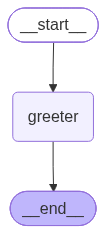

In [5]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
result = app.invoke({'name': "Bob"})

In [7]:
result["name"]

"Hey Bob, you're amazing!"

In [8]:
class MultiAgentState(TypedDict):
    values: List[int]
    name: str
    result: str
    

In [9]:
def process_values(state: MultiAgentState)->MultiAgentState:
    """Handles multiple different inputs"""
    print(state)
    state['result'] = f"Hi there {state['name']}! Your sum = {sum(state['values'])}"
    print(state)
    return state

In [10]:
graph = StateGraph(MultiAgentState)
graph.add_node("processor", process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")
app = graph.compile()

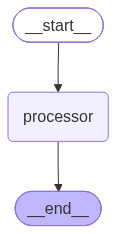

In [11]:
display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
answers = app.invoke({"values": [1, 2, 3, 4], "name": "steve", 'result': "9"})
print(answers["result"])

{'values': [1, 2, 3, 4], 'name': 'steve', 'result': '9'}
{'values': [1, 2, 3, 4], 'name': 'steve', 'result': 'Hi there steve! Your sum = 10'}
Hi there steve! Your sum = 10


In [13]:
class ThirdAgentState(TypedDict):
    name: str
    age: str
    final: str

In [14]:
def first_node(state: ThirdAgentState)-> ThirdAgentState:
    """First node of sequence"""
    state['final'] = f"Hi {state['name']}!"
    return state

def second_node(state: ThirdAgentState)-> ThirdAgentState:
    """Second node of sequence"""
    state['final'] = state['final'] + f" You are {state['age']} years old"
    return state

In [15]:
graph = StateGraph(ThirdAgentState)
graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)

graph.set_entry_point('first_node')
graph.add_edge("first_node", "second_node")
graph.set_finish_point("second_node")
app = graph.compile()

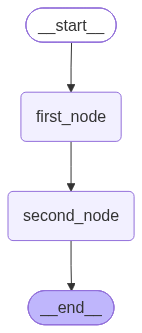

In [16]:
display(Image(app.get_graph().draw_mermaid_png()))

In [17]:
results = app.invoke({'name': "Charlie", "age":20})
print(results['final'])

Hi Charlie! You are 20 years old


In [18]:
class SkillAgentState(TypedDict):
    name: str
    age: str
    skills: list
    output: str

def first_node(state: SkillAgentState)-> SkillAgentState:
    state['output'] = f"Hi {state['name']}, welcome to the system!"
    return state

def second_node(state: SkillAgentState)-> SkillAgentState:
    state['output'] += f" You are {state['age']} years old!"
    return state

def third_node(state: SkillAgentState)-> SkillAgentState:
    items_list = ", ".join([i for i in state['skills']])
    state['output'] += f" You have skills in: {items_list}"
    return state
    

In [19]:
graph = StateGraph(SkillAgentState)
graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)
graph.add_node("third_node", third_node)

graph.set_entry_point('first_node')
graph.add_edge("first_node", "second_node")
graph.add_edge("second_node", "third_node")
graph.set_finish_point('third_node')

app = graph.compile()

In [20]:
result = app.invoke({"name":"Linda", "age": "31", "skills": ["python", "ML", "LG"]})
print(result['output'])

Hi Linda, welcome to the system! You are 31 years old! You have skills in: python, ML, LG


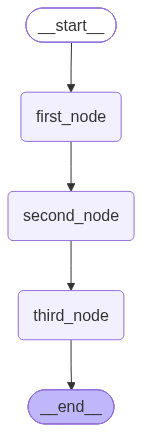

In [21]:
display(Image(app.get_graph().draw_mermaid_png()))

In [22]:
class ConditionalAgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    final_number: int

def adder(state: ConditionalAgentState)-> ConditionalAgentState:
    """Node adds two numbers"""
    state["final_number"] = state['number1'] + state['number2']
    return state

def subtractor(state: ConditionalAgentState)-> ConditionalAgentState:
    """Node minus two numbers"""
    state["final_number"] = state['number1'] - state['number2']
    return state

def decide_next_node(state: ConditionalAgentState)-> ConditionalAgentState:
    """Select next phase of the graph"""
    if state['operation'] == "+":
        return "addition_operation"
    elif state['operation'] == "-":
        return "subtration_operation"

graph = StateGraph(ConditionalAgentState)
graph.add_node("add_node", adder)
graph.add_node("sub_node", subtractor)
graph.add_node("router", lambda state:state) # pass through function

graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "addition_operation": "add_node",
        "subtration_operation": "sub_node"
    }
)

graph.add_edge("add_node", END)
graph.add_edge("sub_node", END)
app = graph.compile()



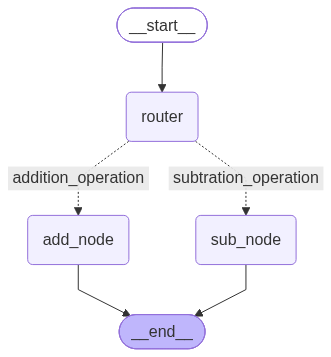

In [23]:
display(Image(app.get_graph().draw_mermaid_png()))

In [24]:
initial_state_1 = ConditionalAgentState(number1=10, operation="-", number2=2)
print(app.invoke(initial_state_1))


{'number1': 10, 'operation': '-', 'number2': 2, 'final_number': 8}


In [25]:
class LoopAgentState(TypedDict):
    name: str
    number: List[int]
    counter: int

def greeter_node(state: LoopAgentState)-> LoopAgentState:
    """Greets"""
    state["name"] = f"Hi there, {state['name']}"
    state['counter'] = 0
    return state

def random_node(state: LoopAgentState)-> LoopAgentState:
    """generates random number"""
    state['number'].append(random.randint(0,10))
    state['counter'] += 1
    return state

def should_countine(state: LoopAgentState)-> LoopAgentState:
    "function decidide next"
    if state['counter'] < 5:
        print("entering loop", state['counter'])
        return "loop"
    else:
        return "exit"
        


In [26]:
graph = StateGraph(LoopAgentState)
graph.add_node("greeter", greeter_node)
graph.add_node("random", random_node)

graph.add_edge(START, "greeter")
graph.add_edge("greeter", "random")
graph.add_conditional_edges(
    "random",
    should_countine,
    {
        "loop": "random",
        "exit": END
    }
)

app = graph.compile()

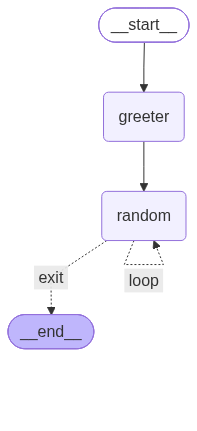

In [27]:
display(Image(app.get_graph().draw_mermaid_png()))

In [28]:
print(app.invoke({"name": "Suzana", "number": []}))

entering loop 1
entering loop 2
entering loop 3
entering loop 4
{'name': 'Hi there, Suzana', 'number': [9, 1, 5, 2, 2], 'counter': 5}
